# 无监督学习 降维

https://www.runoob.com/ml/ml-dimensionality-reduction.html

在机器学习中，我们常常面临类似的困境：数据集拥有成百上千个特征（维度）。这不仅会导致计算速度极慢（维度灾难），还可能因为许多特征是冗余或无关的，反而干扰我们找到数据中真正的规律。

降维（Dimensionality Reduction），就是无监督学习中的一种核心技术，它像一位数据健身教练，帮助我们将高维数据减肥到低维空间，同时尽可能保留最重要的信息。今天，我们就来深入浅出地学习降维。

## 降维的基本概念

简单来说，降维就是减少数据集特征数量的过程。它通过某种数学变换，将原始高维空间中的数据点，映射到一个新的、维度更低的空间中。

### 为什么要降维？

降维绝非简单地丢弃数据，其核心价值在于：

- 可视化：人类最多能直观理解三维空间。通过降维到 2D 或 3D，我们可以将高维数据画出来，直观地观察其结构、分组和异常点。
- 提升效率：更少的数据维度意味着更小的存储空间、更快的训练速度和更低的计算成本。
- 去除噪声与冗余：许多算法（尤其是距离计算类算法如KNN）在高维空间中会因不相关或重复的特征而性能下降。降维可以提炼出数据的精华。
- 缓解维度灾难：在高维空间中，数据会变得极其稀疏，导致许多机器学习模型难以找到有效的模式。

### 核心思想：信息保留

降维的关键挑战是：如何在降低维度的同时，最大限度地保留原始数据中有价值的信息（如方差、数据结构）？ 不同的降维算法对此有不同的答案。

## 主流降维算法详解

降维算法主要分为两大类：线性降维 和 非线性降维。

### 线性降维：主成分分析

主成分分析（PCA） 是最经典、最常用的线性降维方法。它的目标是为数据找到一组新的坐标轴（称为"主成分"），使得数据在这些新轴上的投影方差最大。

- 中心化：将每个特征减去其平均值，使数据分布的中心移动到坐标原点。
- 计算协方差矩阵：这个矩阵描述了数据各个特征之间的相关性。
- 特征值分解：计算协方差矩阵的特征值和特征向量。特征向量 指明了新坐标轴（主成分）的方向，特征值 则代表了数据在该方向上的方差大小。特征值越大，该方向包含的信息越多。
选择主成分：将特征值从大到小排序，选择前 k 个最大的特征值对应的特征向量，构成一个投影矩阵。
- 数据转换：将原始数据乘以这个投影矩阵，就得到了降维到 k 维的新数据。

原始数据形状: (150, 4)
降维后数据形状: (150, 2)
各主成分解释的方差比例: [0.92461872 0.05306648]


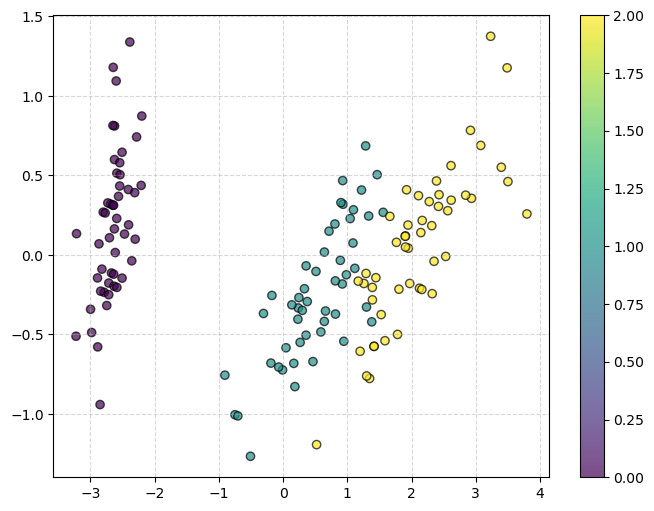

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

# 1. 加载经典的鸢尾花数据集（4个特征）
iris = load_iris()
X = iris.data  # 原始数据：150个样本，4个特征
y = iris.target # 标签，用于可视化着色

print(f"原始数据形状: {X.shape}")  # 输出: (150, 4)

# 2. 创建PCA模型，指定降维到2维
pca = PCA(n_components=2)

# 3. 拟合模型（计算主成分）并转换数据
X_pca = pca.fit_transform(X)

print(f"降维后数据形状: {X_pca.shape}") # 输出: (150, 2)
print(f"各主成分解释的方差比例: {pca.explained_variance_ratio_}")
# 输出可能类似: [0.9246, 0.0530] 表示第一主成分保留了92.5%的信息，第二主成分保留了5.3%

# 4. 可视化降维结果
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, edgecolor='k', alpha=0.7)
plt.colorbar(scatter)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

- PCA(n_components=2)：初始化模型，n_components 参数指定要保留的主成分数量（即降维后的维度）。
- fit_transform(X)：这是一个组合方法，先计算数据的均值和主成分方向（fit），然后立即将数据转换到新空间（transform）。
- explained_variance_ratio_：这是PCA一个非常重要的属性，它告诉我们每个新特征（主成分）保留了原始数据多少的方差（信息量）。这帮助我们决定选择多少个主成分是合适的。

PCA 的优缺点
- 优点：计算高效，原理清晰，能有效去除线性相关性。
- 缺点：它是一种线性方法，假设数据的主成分是线性的。对于像"瑞士卷"这样的非线性流形数据，PCA效果不佳。

### 非线性降维：t-SNE

当数据具有复杂的非线性结构时，我们需要非线性降维方法。t-分布随机邻域嵌入（t-SNE） 是当前最流行的可视化导向的非线性降维算法。

t-SNE 专注于保留数据的局部结构。它试图让在高维空间中"相似"（距离近）的点，在低维映射中也"相似"；而高维中"不相似"的点，在低维中则远离。

瑞士卷数据形状: (1000, 3)


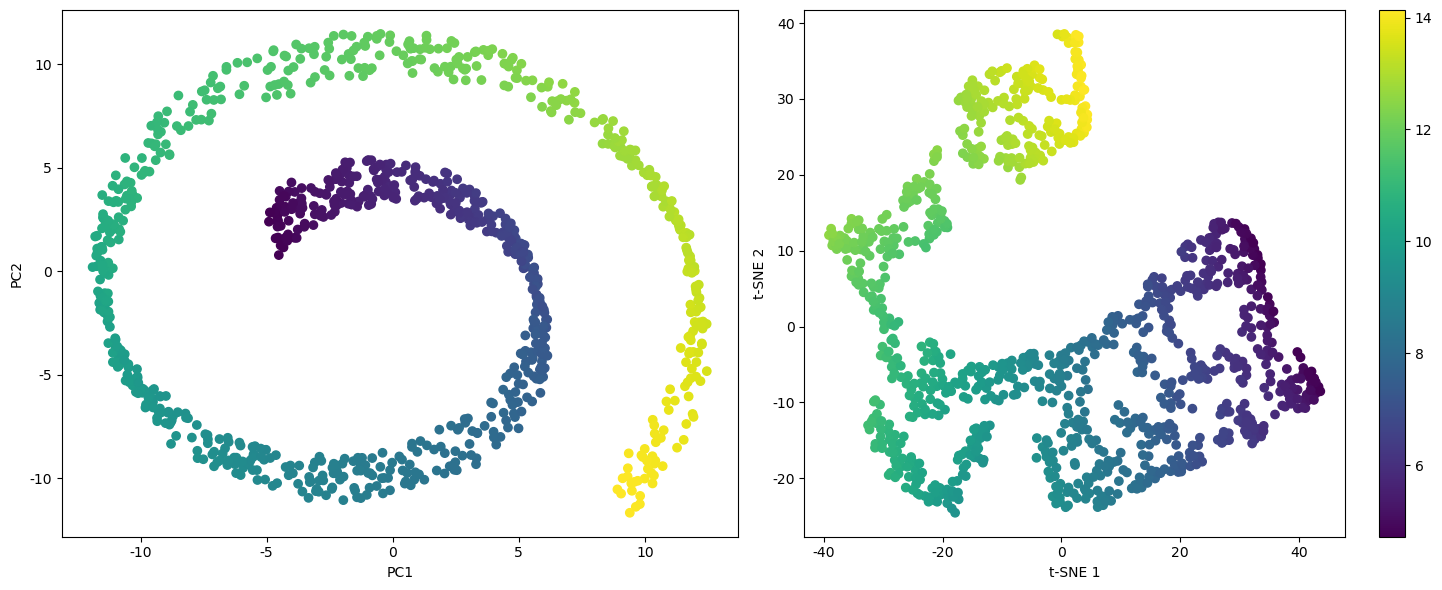

In [5]:
# 导入必要的库
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.datasets import make_swiss_roll # 生成瑞士卷数据

# 1. 生成一个非线性数据集：瑞士卷
X_swiss, color = make_swiss_roll(n_samples=1000, noise=0.1)
print(f"瑞士卷数据形状: {X_swiss.shape}") # (1000, 3)

# 2. 使用PCA（线性方法）尝试降维
pca = PCA(n_components=2)
X_swiss_pca = pca.fit_transform(X_swiss)

# 3. 使用t-SNE（非线性方法）降维
# perplexity（困惑度）是t-SNE的关键参数，通常介于5到50之间，表示对局部/全局结构的平衡关注
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_swiss_tsne = tsne.fit_transform(X_swiss)

# 4. 对比可视化
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# PCA结果
axes[0].scatter(X_swiss_pca[:, 0], X_swiss_pca[:, 1], c=color, cmap='viridis')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# t-SNE结果
sc = axes[1].scatter(X_swiss_tsne[:, 0], X_swiss_tsne[:, 1], c=color, cmap='viridis')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')

plt.colorbar(sc, ax=axes[1])
plt.tight_layout()
plt.show()

代码解读：

- perplexity 参数：可以理解为对每个点考虑多少个近邻。值小则更关注局部结构，值大则更关注全局结构。它是t-SNE最重要的调参对象。
- random_state：确保结果可复现，因为t-SNE的优化过程是随机的。
- 从可视化结果可以清晰看到，PCA将瑞士卷"压扁"了，丢失了其非线性卷曲结构；而t-SNE则更好地在二维平面上展开了这个卷，保留了数据的局部邻接关系。

t-SNE的优缺点
- 优点：对复杂非线性数据的可视化效果极佳，能清晰展现聚类结构。

- 缺点：

- 计算速度慢，不适合大数据集。
- 结果具有随机性，每次运行可能略有不同。
- 超参数敏感，perplexity 需要调整。
- 主要用于可视化（2D/3D），降维后的特征通常不用于后续的机器学习任务，因为其低维空间的距离意义发生了变化。